<a href="https://colab.research.google.com/github/Heoyuna0819/machine_learning/blob/main/AE_wisdm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

In [2]:
#1. Load & Clean
names = ["user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis", "NaN"]
df = pd.read_csv("/content/drive/MyDrive/WISDM_ar_v1.1_raw.txt",
                 header=None, names=names, comment=';')

df = df.drop(columns=["NaN"])
# 세미콜론/문자 → 숫자
for col in ["x_axis", "y_axis", "z_axis"]:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(";", "", regex=True), errors="coerce")

# 결측치 제거
df = df.dropna().reset_index(drop=True)
df = df.drop(['user_id', 'timestamp'], axis=1)

In [3]:
df.head()

,activity,x_axis,y_axis,z_axis
0,Jogging,-0.694638,12.680544,0.503953
1,Jogging,5.012288,11.264028,0.953424
2,Jogging,4.903325,10.882658,-0.081722
3,Jogging,-0.612916,18.496431,3.023717
4,Jogging,-1.184970,12.108489,7.205164


In [4]:
df.isnull().values.any()

np.False_

In [6]:
# 2. Walking & Jogging만 선택
df = df[df["activity"].isin(["Walking", "Jogging"])].reset_index(drop=True)

df["label"] = df["activity"].apply(lambda x: 0 if x == "Walking" else 1)
df=df.drop("activity",axis=1)

In [7]:
# 3. Scaling
X = df.drop("label", axis=1)
y = df["label"]

scaler = StandardScaler()
scaler.fit(X[y == 0])          # 정상 데이터 기준 스케일링
X_scaled = scaler.transform(X)

# 정상 데이터만 학습
X_train = X_scaled[y == 0]
X_test = X_scaled
y_test = y

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (424397, 3)
X_test : (766573, 3)


In [9]:
#4.  Autoencoder Model
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))
x = Dense(32, activation='relu')(input_layer)
x = Dense(16, activation='relu')(x)
encoded = Dense(8, activation='relu')(x)

x = Dense(16, activation='relu')(encoded)
x = Dense(32, activation='relu')(x)
decoded = Dense(input_dim, activation='sigmoid')(x)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(0.001), loss='mse')

Epoch 1/80
11937/11937 ━━━━━━━━━━━━━━━━━━━━ 59s 5ms/step - loss: 0.3022 - val_loss: 0.2719
Epoch 2/80
11937/11937 ━━━━━━━━━━━━━━━━━━━━ 54s 5ms/step - loss: 0.2634 - val_loss: 0.2710
Epoch 3/80
11937/11937 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 0.2616 - val_loss: 0.2710
Epoch 4/80
11937/11937 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.2614 - val_loss: 0.2709
Epoch 5/80
11937/11937 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.2625 - val_loss: 0.2709
Epoch 6/80
11937/11937 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.2606 - val_loss: 0.2709
Epoch 7/80
11937/11937 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 0.2618 - val_loss: 0.2709
Epoch 8/80
11937/11937 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 0.2625 - val_loss: 0.2709
Epoch 9/80
11937/11937 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - loss: 0.2627 - val_loss: 0.2710
Epoch 10/80
11937/11937 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - loss: 0.2620 - val_loss: 0.2709
Epoch 11/80
11937/11937 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 0.2617 - val_loss: 0.27

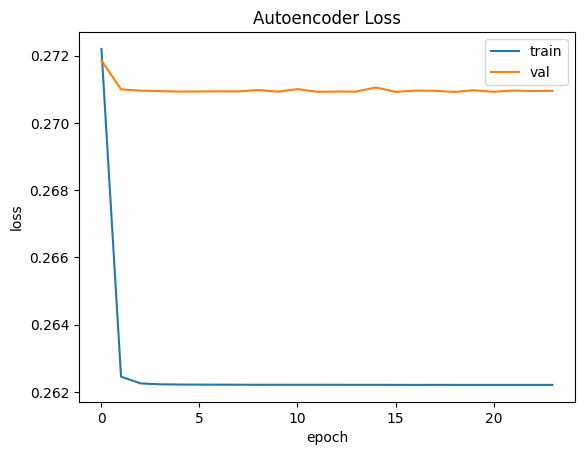

In [16]:
# 5. Training (EarlyStopping 적용)
es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train, X_train,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    shuffle=True,
    verbose=1
)

# Loss 그래프
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Autoencoder Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [18]:
# 6. Reconstruction Error

pred = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - pred, 2), axis=1)

error_df = pd.DataFrame({
    "reconstruction_error": mse,
    "true_class": y_test
})

print(error_df.describe())


23956/23956 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step
       reconstruction_error     true_class
count          7.665730e+05  766573.000000
mean           5.933568e-01       0.446371
std            9.436489e-01       0.497116
min            1.814470e-07       0.000000
25%            5.527295e-02       0.000000
50%            2.308344e-01       0.000000
75%            6.907045e-01       1.000000
max            1.059428e+01       1.000000


In [20]:
# 7. Best Threshold using F1-score
best_f1 = -1
best_thres = 0

test_errors = error_df["reconstruction_error"].values

for t in np.linspace(test_errors.min(), test_errors.max(), 200):
    y_pred_temp = (test_errors > t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_thres = t

print("\nBest Threshold:", best_thres)
print(" Best F1-score:", best_f1)

# 최종 예측
y_pred = (test_errors > best_thres).astype(int)



Best Threshold: 0.15971296548007297
 Best F1-score: 0.7025908109444746


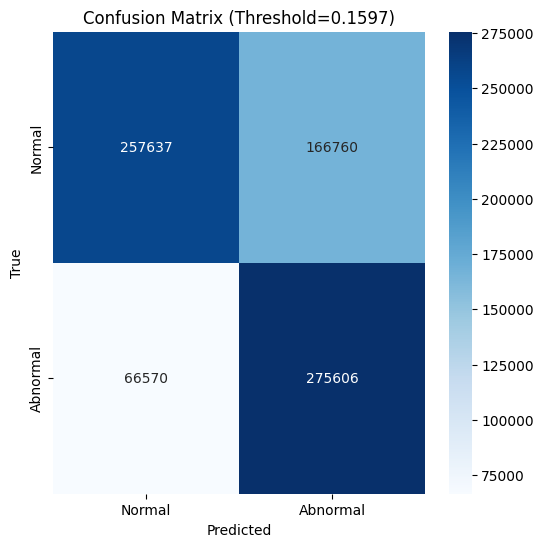


Classification Report
              precision    recall  f1-score   support

      Normal       0.79      0.61      0.69    424397
    Abnormal       0.62      0.81      0.70    342176

    accuracy                           0.70    766573
   macro avg       0.71      0.71      0.70    766573
weighted avg       0.72      0.70      0.69    766573



In [21]:
# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Abnormal"],
            yticklabels=["Normal", "Abnormal"])
plt.title(f"Confusion Matrix (Threshold={best_thres:.4f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=["Normal", "Abnormal"]))

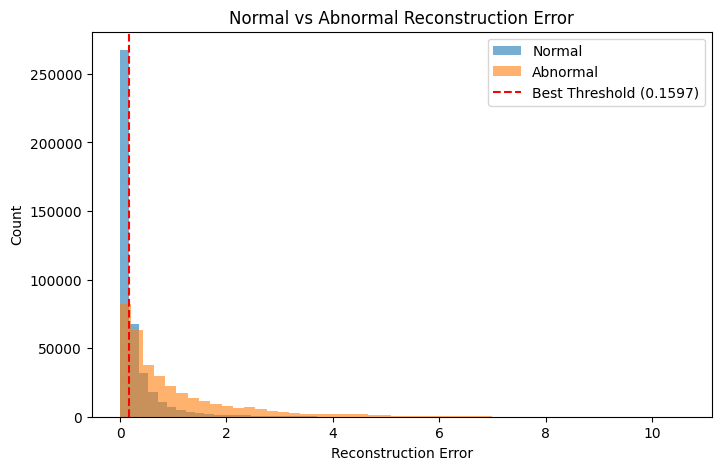

In [22]:
# 9. Error Distribution Plot
plt.figure(figsize=(8,5))
plt.hist(error_df[error_df['true_class']==0]['reconstruction_error'], bins=50, alpha=0.6, label='Normal')
plt.hist(error_df[error_df['true_class']==1]['reconstruction_error'], bins=50, alpha=0.6, label='Abnormal')
plt.axvline(best_thres, color='red', linestyle='--', label=f"Best Threshold ({best_thres:.4f})")
plt.legend()
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Normal vs Abnormal Reconstruction Error")
plt.show()